# Notebook 07 — Évaluation finale : comparaison des modèles et portefeuilles long-short

**Objectif de ce notebook :**
- **Partie A — Comparaison du R²_oos** : charger les résultats déjà sauvegardés par les 3
  modèles (régression linéaire, Elastic Net, LightGBM), les comparer statistiquement sur
  `train`/`validation`/`test` (chacun **pooled sur toutes les fenêtres**, voir notebooks
  04-06), diagnostiquer un éventuel sur-apprentissage, et regarder l'évolution du R²_oos test
  fenêtre par fenêtre
- **Partie B — Portefeuilles long-short par décile** : traduire les prédictions de chaque
  modèle en portefeuille investissable (achat du décile prédit le plus haut, vente à découvert
  du décile le plus bas), et évaluer leur performance avec des mesures financières standard
  (Sharpe, Sortino, drawdown maximum, significativité statistique...)
- **Synthèse finale** : le modèle le plus précis statistiquement (`R²_oos`) est-il aussi celui
  qui dégage le meilleur portefeuille (`Sharpe`) ? Un bon `R²_oos` ne garantit pas
  automatiquement une bonne stratégie d'investissement — voir la synthèse en fin de notebook.

⚠️ **Pré-requis : avoir déjà exécuté les notebooks 04, 05 et 06** (les 3 modèles), qui
produisent `outputs/resultats_*.parquet` et surtout `outputs/predictions_*.parquet` — **aucun
ré-entraînement, et aucun rechargement de modèle `.joblib`, n'est fait ici.**

ℹ️ **Comment ce notebook consomme les modèles.** Chaque modèle (04-06) a été ré-entraîné
plusieurs fois sur des fenêtres qui avancent dans le temps, et a déjà sauvegardé ses
**prédictions de test pooled** (une ligne par `permno`/`annee_mois`, toutes fenêtres mises
bout à bout) dans `outputs/predictions_*.parquet`. Ce notebook se contente donc de **charger
ces prédictions directement** — pas besoin de recharger un modèle ni de re-prédire quoi que
ce soit.

ℹ️ **Pourquoi regrouper la comparaison statistique et les portefeuilles dans un même
notebook ?** Ce sont les deux faces d'une même question — « quel modèle choisir au final ? »
— vue sous deux angles complémentaires (statistique, puis économique). Les regrouper permet
la synthèse finale ci-dessous, impossible à faire séparément.

ℹ️ **Ce notebook fait partie du pipeline automatique du notebook 00**
(`pipeline.py`, voir `GRAPHE_DEPENDANCES`) -- il se relance automatiquement dès que l'un des
3 modèles (ou `NB_DECILES`) change, en plus de pouvoir toujours être relancé à la main. Sa
partie B (section B.6) tague chaque modèle avec sa `cle_experience` (déjà écrite dans
`outputs/resultats_*.parquet` par 04/05/06, section 7), et **ajoute** (sans jamais rien
écraser, section B.8) ses mesures de portefeuille à
`outputs/historique_performance_portefeuilles.parquet` -- c'est ce qui permet au
**notebook 08** d'afficher, en plus du `R²_oos`, les mêmes mesures de portefeuille (Sharpe,
Sortino...) de **chaque** expérience du journal déjà évaluée par 07 (pas seulement la
dernière), directement dans ses tableaux de comparaison (voir sa section 2).

## 0. Import des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os
import sys
sys.path.append("..")  # pour pouvoir importer config.py et journal.py, situes a la racine du projet
import config
import journal

config.assurer_dossiers()  # cree data/interim, data/processed, modeles/, outputs/ si absents

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

## Partie A — Comparaison du R²_oos

1. Charger les résultats déjà sauvegardés par les notebooks **régression linéaire simple**,
   **Elastic Net** et **LightGBM** — **sans ré-entraîner aucun modèle**
2. Les comparer côte à côte sur `train` / `validation` / `test` (chacun pooled sur toutes les
   fenêtres de chaque modèle)
3. Visualiser la comparaison, et l'évolution du R²_oos test fenêtre par fenêtre
4. Diagnostiquer un éventuel sur-apprentissage
5. Conclure lequel des trois modèles généralise le mieux, au sens statistique

⚠️ **Pré-requis : avoir déjà exécuté les notebooks des 3 modèles**, qui produisent
`outputs/resultats_regression_lineaire.parquet`, `outputs/resultats_elastic_net.parquet` et
`outputs/resultats_lightgbm.parquet` (résumés pooled), ainsi que leurs équivalents
`_par_fenetre.parquet` (détail par fenêtre).

### A.1 Chargement des résultats sauvegardés

In [2]:
modeles_info = [
    # (nom affiche, cle courte pour les noms de colonnes)
    ('Regression lineaire', 'reg_lineaire'),
    ('Elastic Net',         'elastic_net'),
    ('LightGBM',            'lightgbm'),
]

fichiers_resultats = {
    "Regression lineaire": config.FICHIER_RESULTATS_REGRESSION_LINEAIRE,
    "Elastic Net": config.FICHIER_RESULTATS_ELASTIC_NET,
    "LightGBM": config.FICHIER_RESULTATS_LIGHTGBM,
}
fichiers_resultats_par_fenetre = {
    "Regression lineaire": config.FICHIER_RESULTATS_REGRESSION_LINEAIRE_PAR_FENETRE,
    "Elastic Net": config.FICHIER_RESULTATS_ELASTIC_NET_PAR_FENETRE,
    "LightGBM": config.FICHIER_RESULTATS_LIGHTGBM_PAR_FENETRE,
}
fichiers_predictions = {
    "Regression lineaire": ('reg_lineaire', config.FICHIER_PREDICTIONS_REGRESSION_LINEAIRE),
    "Elastic Net": ('elastic_net', config.FICHIER_PREDICTIONS_ELASTIC_NET),
    "LightGBM": ('lightgbm', config.FICHIER_PREDICTIONS_LIGHTGBM),
}

fichiers_manquants = [
    nom for nom, chemin in fichiers_resultats.items() if not os.path.exists(chemin)
] + [
    nom for nom, (_, chemin) in fichiers_predictions.items() if not os.path.exists(chemin)
]
assert not fichiers_manquants, (
    f"Fichiers introuvables pour : {sorted(set(fichiers_manquants))}. "
    "Execute d'abord le(s) notebook(s) correspondant(s) (04/05/06) avant de continuer."
)
print("OK : les fichiers de resultats et de predictions des 3 modeles sont presents.")

OK : les fichiers de resultats et de predictions des 3 modeles sont presents.


In [3]:
resultats = pd.concat(
    [pd.read_parquet(chemin) for chemin in fichiers_resultats.values()],
    ignore_index=True,
)

resultats[['modele', 'type_fenetre', 'n_fenetres', 'r2_oos_train', 'r2_oos_validation', 'r2_oos_test']]

,modele,type_fenetre,n_fenetres,r2_oos_train,r2_oos_validation,r2_oos_test
0,Regression lineaire,expanding,3,0.005177,0.001667,0.002168
1,Elastic Net,expanding,3,0.002970,0.002239,0.003809
2,LightGBM,expanding,3,0.018181,0.004395,0.002829


### A.2 Comment lire ces résultats

Rappel : le `R²_oos` compare les erreurs du modèle à une prédiction naïve de **zéro** (pas
la moyenne). Quelques repères pour interpréter :

- **`R²_oos` proche de 0 ou légèrement positif** (même 0.3-1%) : normal et considéré comme
  un résultat notable dans la littérature sur la prédiction de rendements boursiers — ces
  données sont extrêmement bruitées par nature.
- **`R²_oos` négatif** : le modèle fait **pire** que de prédire systématiquement zéro — un
  signal que le modèle (ou ses hyperparamètres) ne généralise pas.
- **Ce qui compte le plus : le score sur `test`**, pas sur `train`. Un score élevé sur
  `train` ne garantit rien sur la capacité du modèle à généraliser.
- Chaque colonne (`train`/`validation`/`test`) est **pooled sur toutes les
  fenêtres** de ce modèle (voir notebooks 04-06, section 4) — pas juste une seule période,
  donc moins sensible au hasard d'avoir choisi une bonne ou une mauvaise décennie de test.
- La **régression linéaire simple** sert de plancher de comparaison : elle n'a aucune
  régularisation, donc si l'Elastic Net et/ou LightGBM ne font pas mieux qu'elle sur
  `test`, leur complexité supplémentaire n'apporte rien de concret sur ces données.

### A.3 Diagnostic de sur-apprentissage

Si le score sur `train` est beaucoup plus élevé que sur `validation`/`test`, le modèle a
probablement **appris du bruit spécifique aux données d'entraînement** plutôt qu'un vrai
signal généralisable. C'est un risque particulièrement pertinent pour la régression
linéaire simple, qui n'a justement aucune régularisation pour s'en protéger.

In [4]:
resultats['ecart_train_test'] = resultats['r2_oos_train'] - resultats['r2_oos_test']

for _, ligne in resultats.iterrows():
    print(f"{ligne['modele']:22s} -> ecart train-test : {ligne['ecart_train_test']:.4f}")
    if ligne['ecart_train_test'] > 0.02:
        print("   ATTENTION : ecart important, signe possible de sur-apprentissage.")

Regression lineaire    -> ecart train-test : 0.0030
Elastic Net            -> ecart train-test : -0.0008
LightGBM               -> ecart train-test : 0.0154


### A.4 Visualisation comparative

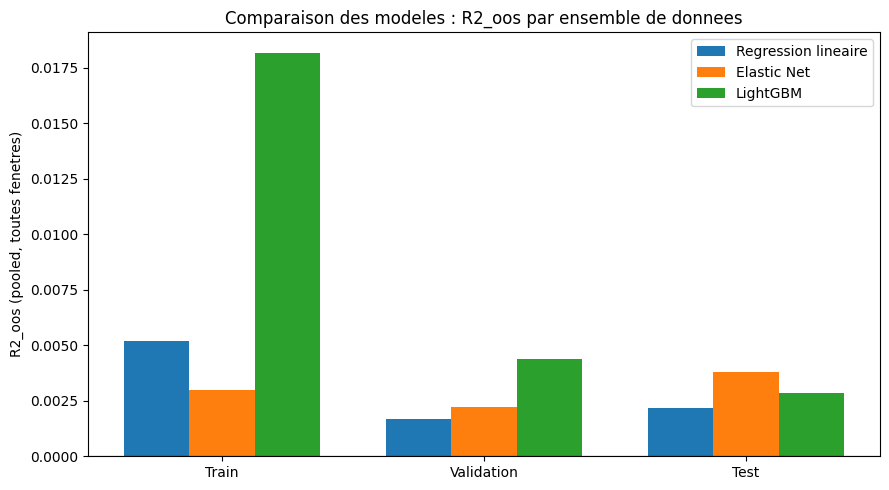

In [5]:
ensembles = ['r2_oos_train', 'r2_oos_validation', 'r2_oos_test']
etiquettes = ['Train', 'Validation', 'Test']

fig, ax = plt.subplots(figsize=(9, 5))

largeur_barre = 0.25
positions = range(len(ensembles))

for i, (_, ligne) in enumerate(resultats.iterrows()):
    valeurs = [ligne[col] for col in ensembles]
    decalage = [p + i * largeur_barre for p in positions]
    ax.bar(decalage, valeurs, width=largeur_barre, label=ligne['modele'])

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks([p + largeur_barre for p in positions])
ax.set_xticklabels(etiquettes)
ax.set_ylabel("R2_oos (pooled, toutes fenetres)")
ax.set_title("Comparaison des modeles : R2_oos par ensemble de donnees")
ax.legend()
plt.tight_layout()

plt.savefig(config.FICHIER_COMPARAISON_PNG, dpi=150)
plt.show()

### A.5 Évolution du R²_oos test au fil des fenêtres, par modèle

Les fenêtres glissantes/extensives permettent de voir **quand** chaque modèle est bon ou
mauvais — utile pour repérer des périodes difficiles pour tous les modèles à la fois (crises,
changements de régime de marché) plutôt que des différences propres à un seul modèle.

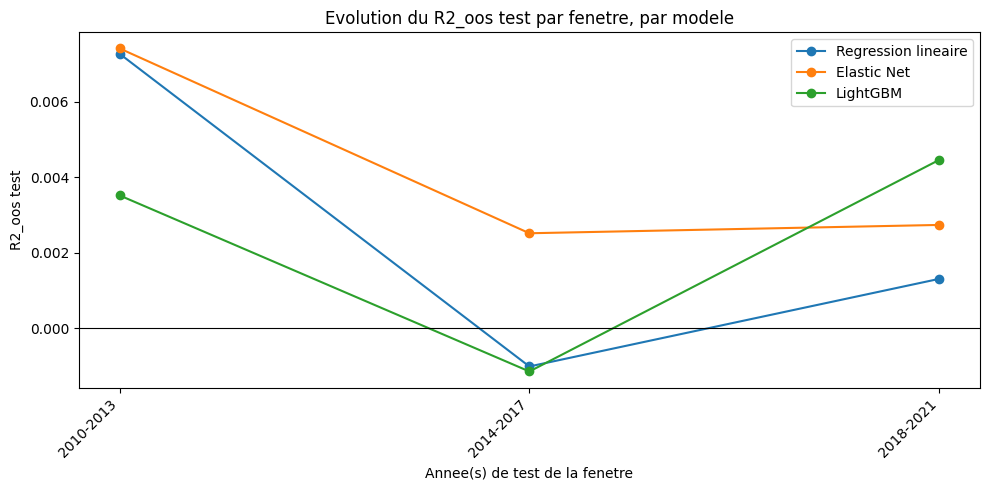

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

for nom, chemin in fichiers_resultats_par_fenetre.items():
    detail = pd.read_parquet(chemin)
    ax.plot(detail['annee_test'], detail['r2_oos_test'], marker='o', label=nom)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel("Annee(s) de test de la fenetre")
ax.set_ylabel("R2_oos test")
ax.set_title("Evolution du R2_oos test par fenetre, par modele")
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(config.FICHIER_EVOLUTION_R2_PNG, dpi=150)
plt.show()

### A.6 Conclusion et sauvegarde

In [7]:
meilleur_modele = resultats.loc[resultats['r2_oos_test'].idxmax()]

print(f"Meilleur modele sur TEST (pooled) : {meilleur_modele['modele']} "
      f"(R2_oos test = {meilleur_modele['r2_oos_test']:.4f})")
print()
print("Rappel : c'est le score sur TEST qui doit guider ce choix, pas celui sur train.")

Meilleur modele sur TEST (pooled) : Elastic Net (R2_oos test = 0.0038)

Rappel : c'est le score sur TEST qui doit guider ce choix, pas celui sur train.


In [8]:
resultats.to_parquet(config.FICHIER_COMPARAISON_PARQUET, index=False)
print("Comparaison sauvegardee   :", config.FICHIER_COMPARAISON_PARQUET)
print("Graphique sauvegarde      :", config.FICHIER_COMPARAISON_PNG)
print("Evolution par fenetre     :", config.FICHIER_EVOLUTION_R2_PNG)

Comparaison sauvegardee   : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\comparaison_modeles.parquet
Graphique sauvegarde      : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\comparaison_modeles.png
Evolution par fenetre     : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\evolution_r2_oos_par_fenetre.png


**Résumé de la partie A :** comparaison faite uniquement à partir des résultats déjà
sauvegardés (aucun ré-entraînement), chacun pooled sur toutes les fenêtres d'entraînement de
son modèle. Diagnostic de sur-apprentissage via l'écart train/test, et évolution du R²_oos
test fenêtre par fenêtre. Tableaux et graphiques sauvegardés dans `outputs/`. **Rappel :
c'est le score sur `test` qui doit guider la conclusion, pas celui sur `train`.**

## Partie B — Portefeuilles long-short par décile

Le `R²_oos` mesure la précision statistique d'un modèle, mais ne dit rien directement de sa
**valeur économique** : un modèle peut avoir un `R²_oos` légèrement supérieur à un autre tout
en produisant une stratégie d'investissement moins intéressante (moins stable, plus risquée...),
ou inversement. Cette partie traduit les prédictions des 3 modèles en portefeuilles
investissables, pour juger cette valeur économique directement — avec les mesures qu'utilisent
les praticiens de la finance quantitative.

1. Charger les prédictions de test déjà sauvegardées par les notebooks 04, 05 et 06
   (`outputs/predictions_*.parquet`) — **sans aucun ré-entraînement, ni aucun rechargement de
   modèle**
2. Fusionner les 3 tables de prédictions sur `(permno, annee_mois)` en une seule
3. Construire, **mois par mois**, 10 portefeuilles par décile de rendement prédit, en
   pondération égale — la méthode standard en finance quantitative empirique (Fama-French,
   Gu, Kelly & Xiu 2020...) pour transformer un pouvoir prédictif statistique en stratégie
   d'investissement concrète
4. Former le portefeuille **long-short** de chaque modèle : acheter le décile le plus élevé
   (rendement prédit le plus fort), vendre à découvert le décile le plus faible
5. Évaluer chaque portefeuille avec des mesures de performance utilisées en finance
   quantitative : rendement annualisé, volatilité annualisée, ratio de Sharpe, ratio de
   Sortino, drawdown maximum, significativité statistique...

ℹ️ **Sur la période couverte** : avec les fenêtres glissantes/extensives, la période de
« test » n'est plus un seul bloc à la fin du panel, mais **l'union de tous les tests de
toutes les fenêtres** — potentiellement plusieurs décennies mises bout à bout (voir le
résumé des fenêtres au notebook 04, section 1). C'est *plus* représentatif d'une vraie
stratégie d'investissement suivie sur le long terme qu'un seul test récent.

### B.1 Chargement et fusion des prédictions déjà sauvegardées

Chaque fichier `predictions_*.parquet` contient une ligne par `(permno, annee_mois)` de test
(toutes fenêtres confondues pour ce modèle), avec le rendement réellement réalisé
(`excess_return`) et la prédiction du modèle. Les 3 modèles utilisant exactement les mêmes
fenêtres (mêmes paramètres dans `config.py`), leurs 3 tables de test devraient couvrir
exactement les mêmes `(permno, annee_mois)` — on le vérifie avant de fusionner.

In [9]:
tables_predictions = {}
for nom, (cle, chemin) in fichiers_predictions.items():
    table = pd.read_parquet(chemin)
    tables_predictions[cle] = table
    print(f"{nom:22s} : {table.shape}, periode {table['annee_mois'].min()} a {table['annee_mois'].max()}")

Regression lineaire    : (669550, 5), periode 201001 a 202112
Elastic Net            : (669550, 5), periode 201001 a 202112
LightGBM               : (669550, 5), periode 201001 a 202112


In [10]:
# On part de la 1ere table (identifiants + cible) et on ajoute la colonne de prediction
# de chaque modele par une fusion sur (permno, annee_mois) -- 'inner' par securite, au cas
# ou une fenetre de bord differerait legerement d'un modele a l'autre.
cible = config.CIBLE
predictions = None

for nom, (cle, _) in fichiers_predictions.items():
    table = tables_predictions[cle][['permno', 'annee_mois', cible, 'prediction']].rename(
        columns={'prediction': f'pred_{cle}'}
    )
    if predictions is None:
        predictions = table
    else:
        predictions = pd.merge(
            predictions, table.drop(columns=[cible]),
            on=['permno', 'annee_mois'], how='inner',
        )

print(f"Predictions fusionnees : {predictions.shape}")
print(f"Periode couverte : {predictions['annee_mois'].min()} a {predictions['annee_mois'].max()}")
print(f"Nombre de mois distincts : {predictions['annee_mois'].nunique()}")
print(f"Nombre d'entreprises (permno) distinctes : {predictions['permno'].nunique()}")
predictions.head()

Predictions fusionnees : (669550, 6)
Periode couverte : 201001 a 202112
Nombre de mois distincts : 144
Nombre d'entreprises (permno) distinctes : 10080


,permno,annee_mois,excess_return,pred_reg_lineaire,pred_elastic_net,pred_lightgbm
0,10001,201001,-0.018932,0.005855,0.005752,0.018925
1,10002,201001,0.365854,-0.011612,-0.011081,-0.034650
2,10025,201001,-0.088036,0.016756,0.016380,0.018992
3,10026,201001,0.046296,-0.000642,-0.000563,0.000701
4,10032,201001,0.194171,0.016989,0.016626,0.008772


### B.3 Construction des portefeuilles par décile (mois par mois)

Pour chaque modèle et **chaque mois séparément**, on classe les entreprises en 10 groupes
(déciles) selon leur rendement prédit :
- **décile 1** : les prédictions les plus faibles (le modèle anticipe les moins bonnes
  performances)
- **décile 10** : les prédictions les plus élevées (le modèle anticipe les meilleures
  performances)

⚠️ **Pourquoi classer mois par mois, et pas sur toute la période d'un coup ?** Un décile doit
représenter un portefeuille qu'on pourrait *réellement* construire à un instant donné, avec
les entreprises disponibles *ce mois-là*. Classer sur l'ensemble de la période mélangerait des
entreprises de mois différents dans un même "portefeuille", ce qui n'aurait aucun sens
opérationnel.

ℹ️ On utilise `rank(method='first')` avant `qcut` : ça garantit exactement 10 groupes de
taille quasi identique chaque mois, même s'il existe des prédictions strictement égales
(rares mais possibles) — un `qcut` direct sur les prédictions brutes peut échouer ou produire
moins de 10 groupes en présence d'égalités.

In [11]:
NB_DECILES = config.NB_DECILES  # 10 par defaut

def assigner_decile(serie, n=NB_DECILES):
    # Classe une serie en n groupes (deciles), du plus faible (1) au plus eleve (n).
    return pd.qcut(serie.rank(method='first'), n, labels=False) + 1

for nom, (cle, _) in fichiers_predictions.items():
    predictions[f'decile_{cle}'] = (
        predictions.groupby('annee_mois')[f'pred_{cle}'].transform(assigner_decile)
    )

print("Deciles assignes pour les 3 modeles.")
print()
print("Verification : nombre moyen d'entreprises par decile et par mois (doit etre stable "
      "et similaire entre deciles) :")
for nom, (cle, _) in fichiers_predictions.items():
    taille_moyenne = predictions.groupby(['annee_mois', f'decile_{cle}']).size().groupby('annee_mois').mean().mean()
    print(f"  {nom:22s} : ~{taille_moyenne:.0f} entreprises par decile en moyenne chaque mois")

Deciles assignes pour les 3 modeles.

Verification : nombre moyen d'entreprises par decile et par mois (doit etre stable et similaire entre deciles) :
  Regression lineaire    : ~465 entreprises par decile en moyenne chaque mois
  Elastic Net            : ~465 entreprises par decile en moyenne chaque mois
  LightGBM               : ~465 entreprises par decile en moyenne chaque mois


### B.4 Rendement mensuel de chaque décile, et portefeuille long-short

Pour chaque modèle, le rendement d'un décile un mois donné est la **moyenne équipondérée**
du rendement (réellement réalisé, pas prédit) des entreprises classées dans ce décile ce
mois-là. Le portefeuille **long-short** achète le décile 10 et vend à découvert le décile 1 :
son rendement mensuel est simplement la différence des deux.

C'est la construction standard d'un "portefeuille de spread" en finance quantitative
empirique : si le modèle a un vrai pouvoir prédictif, ce portefeuille doit dégager un
rendement positif et statistiquement significatif, sans qu'on ait besoin de connaître le
signe ou l'ampleur exacte du rendement du marché.

In [12]:
rendements_deciles = {}   # cle -> DataFrame (index=annee_mois, colonnes=1..NB_DECILES)
rendements_ls = {}        # cle -> Series (index=annee_mois), portefeuille long-short

for nom, (cle, _) in fichiers_predictions.items():
    tableau = (
        predictions.groupby(['annee_mois', f'decile_{cle}'])[cible]
        .mean()
        .unstack(f'decile_{cle}')
        .sort_index()
    )
    rendements_deciles[cle] = tableau
    rendements_ls[cle] = tableau[NB_DECILES] - tableau[1]

rendements_portefeuilles = pd.DataFrame({
    nom: rendements_ls[cle] for nom, (cle, _) in fichiers_predictions.items()
})

print("Rendements mensuels des portefeuilles long-short (decile 10 - decile 1), extrait :")
rendements_portefeuilles.head()

Rendements mensuels des portefeuilles long-short (decile 10 - decile 1), extrait :


,Regression lineaire,Elastic Net,LightGBM
annee_mois,,,
201001,-0.006718,-0.006398,0.000566
201002,0.038495,0.039994,0.015418
201003,0.023871,0.021933,0.038357
201004,0.012254,0.013657,0.069090
201005,0.009469,0.011958,0.021753


### B.5 Mesures de performance financière

On calcule, pour chaque portefeuille long-short, un ensemble de mesures standard en finance
quantitative :

- **Rendement annualisé** : moyenne mensuelle × 12
- **Volatilité annualisée** : écart-type mensuel × √12
- **Ratio de Sharpe** : rendement annualisé / volatilité annualisée. Comme `excess_return`
  est déjà un rendement *excédentaire* (net du taux sans risque, voir notebook 03,
  partie A), on n'a
  pas besoin de soustraire à nouveau `Rfree` : le ratio de Sharpe se calcule directement.
- **Ratio de Sortino** : comme le Sharpe, mais ne pénalise que la volatilité *à la baisse*
  (les mois négatifs) — plus pertinent quand les rendements ne sont pas symétriques.
- **Drawdown maximum** : la pire perte cumulée observée depuis un sommet de richesse
  antérieur, sur toute la période de test.
- **% de mois positifs** : proportion de mois où le portefeuille long-short a un rendement
  positif.
- **t-stat / p-value** : test de significativité du rendement moyen (H0 : rendement moyen
  nul). Un t-stat au-delà de ~2 (en valeur absolue) est généralement considéré comme
  significatif.
- **Asymétrie (skewness) et aplatissement (kurtosis)** : les rendements de portefeuilles
  long-short sont rarement gaussiens — utile pour juger si le Sharpe seul suffit à décrire le
  profil de risque.

In [13]:
def calculer_metriques(rendements, nb_periodes_par_an=12):
    # Calcule un ensemble de mesures de performance financiere standard
    # a partir d'une serie de rendements mensuels (deja nette du taux sans risque).
    r = pd.Series(rendements).dropna().values
    n = len(r)

    moyenne = r.mean()
    ecart_type = r.std(ddof=1)

    rendement_annualise = moyenne * nb_periodes_par_an
    volatilite_annualisee = ecart_type * np.sqrt(nb_periodes_par_an)
    sharpe_ratio = rendement_annualise / volatilite_annualisee if volatilite_annualisee > 0 else np.nan

    # Sortino : ne penalise que la volatilite a la baisse (rendements negatifs)
    downside = np.minimum(r, 0)
    downside_dev = np.sqrt(np.mean(downside ** 2)) * np.sqrt(nb_periodes_par_an)
    sortino_ratio = rendement_annualise / downside_dev if downside_dev > 0 else np.nan

    # Drawdown maximum, a partir de la courbe de richesse cumulee (base 1)
    richesse = np.cumprod(1 + r)
    sommet_cumule = np.maximum.accumulate(richesse)
    drawdown = richesse / sommet_cumule - 1
    max_drawdown = drawdown.min()

    pct_mois_positifs = (r > 0).mean()

    # t-stat / p-value du rendement moyen (test bilateral, H0 : rendement moyen nul)
    t_stat = moyenne / (ecart_type / np.sqrt(n)) if ecart_type > 0 else np.nan
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=n - 1)) if not np.isnan(t_stat) else np.nan

    skewness = stats.skew(r)
    kurtosis = stats.kurtosis(r)  # kurtosis "excess" (0 = gaussien)

    return {
        'rendement_annualise': rendement_annualise,
        'volatilite_annualisee': volatilite_annualisee,
        'sharpe_ratio': sharpe_ratio,
        'sortino_ratio': sortino_ratio,
        'max_drawdown': max_drawdown,
        'pct_mois_positifs': pct_mois_positifs,
        't_stat': t_stat,
        'p_value': p_value,
        'skewness': skewness,
        'kurtosis': kurtosis,
        'n_mois': n,
    }

In [14]:
performance = pd.DataFrame({
    nom: calculer_metriques(rendements_portefeuilles[nom])
    for nom, _ in fichiers_predictions.items()
}).T

performance = performance.sort_values('sharpe_ratio', ascending=False)

# 'cle_experience' identifie, pour CHAQUE modele, A QUEL lancement de 04/05/06 (quels
# parametres generaux + specifiques) ces predictions -- et donc ces mesures de portefeuille
# -- correspondent : la MEME cle deja ecrite dans outputs/resultats_*.parquet (voir
# notebooks 04-06, section 7, et journal.cle_experience_actuelle). Sauvegardee plus bas
# (B.8) dans outputs/performance_portefeuilles.parquet : c'est ce qui permet au notebook 08
# de relier CES mesures a LA BONNE ligne de son tableau de comparaison (voir sa section 2).
performance['cle_experience'] = resultats.set_index('modele')['cle_experience']

print("Performance des portefeuilles long-short (decile 10 - decile 1), par modele :")
performance.drop(columns='cle_experience').round(4)

Performance des portefeuilles long-short (decile 10 - decile 1), par modele :


,rendement_annualise,volatilite_annualisee,sharpe_ratio,sortino_ratio,max_drawdown,pct_mois_positifs,t_stat,p_value,skewness,kurtosis,n_mois
LightGBM,0.1797,0.1199,1.4992,2.9361,-0.2041,0.7014,5.1934,0.0000,-0.0286,1.3007,144.0
Regression lineaire,0.1140,0.1062,1.0737,1.9199,-0.1227,0.6597,3.7193,0.0003,-0.1334,0.0144,144.0
Elastic Net,0.0888,0.1215,0.7306,1.2245,-0.2097,0.6181,2.5310,0.0125,0.1334,1.8240,144.0


### B.6 Le rendement est-il monotone par décile ? (diagnostic de qualité du signal)

Un signe de bonne qualité du signal prédictif : le rendement moyen des déciles devrait
**augmenter globalement du décile 1 au décile 10**. Si le classement du modèle n'a aucune
valeur, les rendements moyens par décile devraient être plats (à peu près identiques quel
que soit le décile) plutôt que croissants.

In [15]:
rendement_moyen_par_decile = pd.DataFrame({
    nom: rendements_deciles[cle].mean()
    for nom, (cle, _) in fichiers_predictions.items()
})
rendement_moyen_par_decile.index.name = 'decile'

print("Rendement mensuel moyen par decile (mise en evidence de la monotonie du signal) :")
rendement_moyen_par_decile.round(4)

Rendement mensuel moyen par decile (mise en evidence de la monotonie du signal) :


,Regression lineaire,Elastic Net,LightGBM
decile,,,
1,0.0032,0.0052,0.0003
2,0.0079,0.0083,0.0060
3,0.0091,0.0100,0.0077
4,0.0092,0.0087,0.0092
5,0.0104,0.0086,0.0096
6,0.0110,0.0102,0.0123
7,0.0111,0.0110,0.0119
8,0.0115,0.0117,0.0120
9,0.0119,0.0117,0.0138


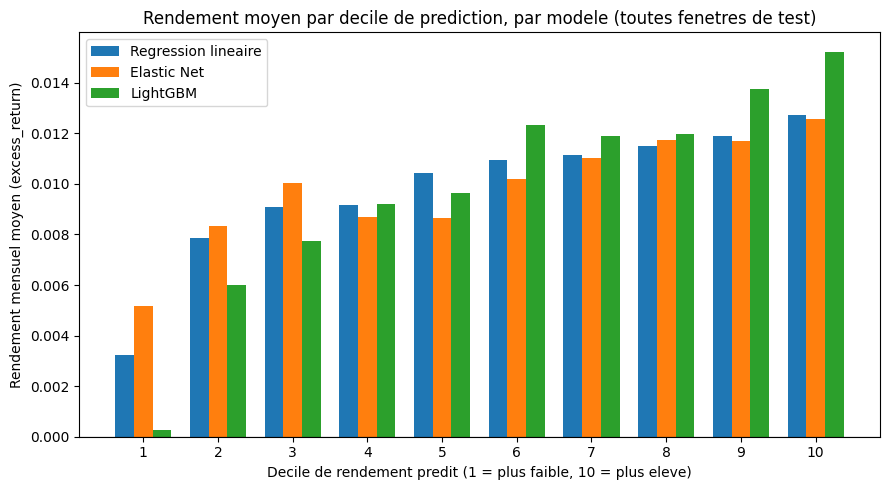

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))

largeur_barre = 0.25
positions = np.arange(NB_DECILES)

for i, (nom, _) in enumerate(fichiers_predictions.items()):
    valeurs = rendement_moyen_par_decile[nom].values
    decalage = positions + i * largeur_barre
    ax.bar(decalage, valeurs, width=largeur_barre, label=nom)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(positions + largeur_barre)
ax.set_xticklabels(range(1, NB_DECILES + 1))
ax.set_xlabel("Decile de rendement predit (1 = plus faible, 10 = plus eleve)")
ax.set_ylabel("Rendement mensuel moyen (excess_return)")
ax.set_title("Rendement moyen par decile de prediction, par modele (toutes fenetres de test)")
ax.legend()
plt.tight_layout()

plt.savefig(config.FICHIER_DECILES_PNG, dpi=150)
plt.show()

### B.7 Richesse cumulée des 3 portefeuilles long-short

On trace la richesse cumulée (base 1, sans capital additionnel ni retrait) de chaque
portefeuille long-short sur toute la période de test (toutes fenêtres mises bout à bout),
pour visualiser à la fois la performance globale et la régularité (ou l'irrégularité) des
gains dans le temps.

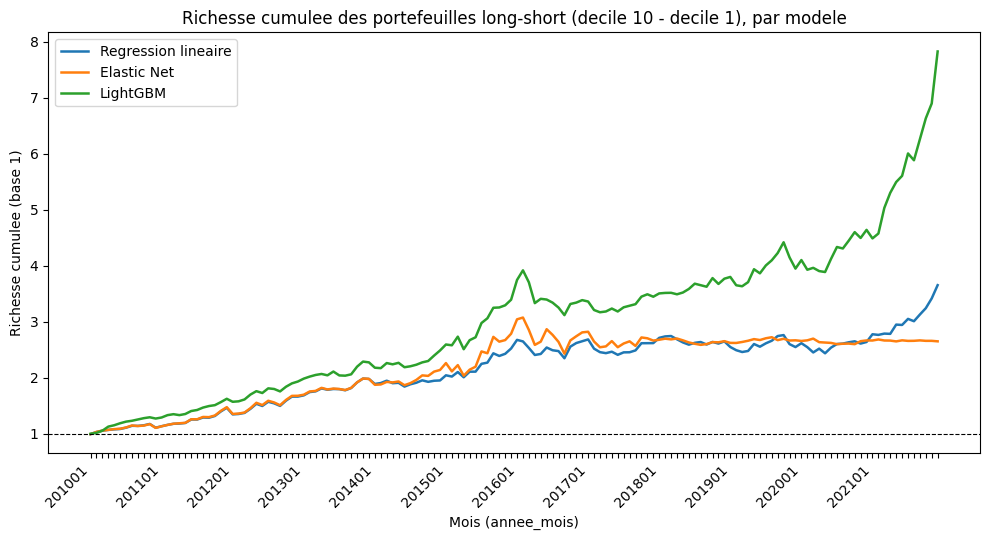

In [17]:
fig, ax = plt.subplots(figsize=(10, 5.5))

for nom, _ in fichiers_predictions.items():
    richesse_cumulee = (1 + rendements_portefeuilles[nom]).cumprod()
    ax.plot(richesse_cumulee.index, richesse_cumulee.values, label=nom, linewidth=1.8)

ax.axhline(1, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel("Mois (annee_mois)")
ax.set_ylabel("Richesse cumulee (base 1)")
ax.set_title("Richesse cumulee des portefeuilles long-short (decile 10 - decile 1), par modele")
ax.legend()

# On n'affiche qu'une etiquette sur ~12 sur l'axe des mois, sinon illisible
nb_mois = len(rendements_portefeuilles.index)
pas_etiquette = max(nb_mois // 12, 1)
ax.set_xticks(ax.get_xticks()[::1])
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
for i, etiquette in enumerate(ax.xaxis.get_ticklabels()):
    if i % pas_etiquette != 0:
        etiquette.set_visible(False)

plt.tight_layout()
plt.savefig(config.FICHIER_CUMULATIF_PNG, dpi=150)
plt.show()

### B.8 Comparaison finale et sauvegarde

⚠️ Comme pour le `R²_oos` en partie A, un ratio de Sharpe élevé ne dit rien à lui seul de
la qualité *économique* du modèle sans regarder aussi le drawdown maximum et la
significativité statistique (`t_stat` / `p_value`) : un Sharpe flatteur porté par 2-3 mois
exceptionnels sur une courte période de test n'a pas la même valeur qu'un Sharpe plus modeste
mais régulier sur une longue période.

ℹ️ **A noter** : en plus du simple instantané `outputs/performance_portefeuilles.parquet`
(écrasé à chaque lancement), ces mesures sont aussi **ajoutées** à
`outputs/historique_performance_portefeuilles.parquet` -- un fichier **jamais écrasé**
(comme `outputs/journal_experiences.parquet`), dédupliqué par `cle_experience` (voir B.5 et
`journal.enregistrer_performances_portefeuilles`) : relancer 07 sur les mêmes prédictions
n'y ajoute rien de plus, mais un changement de modèle/paramètres suivi d'un nouveau
lancement de 07 y **ajoute** une ligne sans supprimer celle du lancement précédent. C'est
cet historique que le notebook 08 utilise pour afficher le Sharpe (etc.) de **chaque**
expérience du journal déjà évaluée par 07 au moins une fois -- `NaN` uniquement pour celles
qui n'ont encore jamais été évaluées (voir sa section 2).

In [18]:
meilleur_modele = performance['sharpe_ratio'].idxmax()
print(f"Meilleur portefeuille long-short sur TEST (ratio de Sharpe) : {meilleur_modele} "
      f"(Sharpe = {performance.loc[meilleur_modele, 'sharpe_ratio']:.3f})")
print()
print(performance.drop(columns='cle_experience').loc[meilleur_modele].round(4))

Meilleur portefeuille long-short sur TEST (ratio de Sharpe) : LightGBM (Sharpe = 1.499)

rendement_annualise        0.1797
volatilite_annualisee      0.1199
sharpe_ratio               1.4992
sortino_ratio              2.9361
max_drawdown              -0.2041
pct_mois_positifs          0.7014
t_stat                     5.1934
p_value                    0.0000
skewness                  -0.0286
kurtosis                   1.3007
n_mois                   144.0000
Name: LightGBM, dtype: float64


In [19]:
rendements_portefeuilles.to_parquet(config.FICHIER_RENDEMENTS_PORTEFEUILLES)
performance.to_parquet(config.FICHIER_PERFORMANCE_PORTEFEUILLES)

print("Rendements mensuels sauvegardes  :", config.FICHIER_RENDEMENTS_PORTEFEUILLES)
print("Tableau de performance sauvegarde:", config.FICHIER_PERFORMANCE_PORTEFEUILLES)
print("Graphique par decile sauvegarde  :", config.FICHIER_DECILES_PNG)
print("Graphique richesse cumulee sauve :", config.FICHIER_CUMULATIF_PNG)

# On AJOUTE (sans rien ecraser) ces mesures a l'historique cumulatif -- voir B.8
# ci-dessus et journal.py. Dedupliqué par cle_experience : relancer 07 sur les memes
# predictions n'ajoute rien de plus.
print()
journal.enregistrer_performances_portefeuilles(performance)
print("Historique cumulatif (jamais ecrase) :", config.FICHIER_HISTORIQUE_PERFORMANCE_PORTEFEUILLES)

Rendements mensuels sauvegardes  : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\rendements_portefeuilles_deciles.parquet
Tableau de performance sauvegarde: C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\performance_portefeuilles.parquet
Graphique par decile sauvegarde  : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\portefeuilles_rendement_par_decile.png
Graphique richesse cumulee sauve : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\portefeuilles_richesse_cumulee.png

Performance de portefeuille ajoutee a l'historique (cle 0206f3484c204bc9) : LightGBM (Sharpe = 1.499)
Historique cumulatif (jamais ecrase) : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\historique_performance_portefeuilles.parquet


**Résumé de la partie B :** portefeuilles long-short construits mois par mois sur
l'ensemble des prédictions de test déjà sauvegardées par 04/05/06 (toutes fenêtres mises bout
à bout). Rendements mensuels et mesures de performance sauvegardés dans
`outputs/rendements_portefeuilles_deciles.parquet` et `outputs/performance_portefeuilles.parquet`
(instantané du dernier lancement), et **ajoutés** (sans rien écraser) à
`outputs/historique_performance_portefeuilles.parquet` (voir B.8) -- c'est ce dernier fichier
que lit le notebook 08 pour afficher ces mesures à côté du `R²_oos` de chaque expérience.

⚠️ **Limites à garder en tête** : portefeuilles équipondérés (pas pondérés par capitalisation,
`mvel1` n'étant plus disponible en valeur brute à ce stade), aucun coût de transaction ni
turnover déduit (borne haute de la performance réellement atteignable), univers déjà restreint
au notebook 03 (grandes capitalisations liquides uniquement), t-stat classique qui suppose des
rendements indépendants d'un mois à l'autre (correct ici puisque le rebalancement est mensuel
et non chevauchant), et un ré-entraînement plus fréquent
(`ANNEES_TEST_PAR_FENETRE` petit) augmente le nombre de modèles utilisés dans la période de
test mais aussi le coût de calcul total (voir notebooks 04-06).

## Synthèse finale — précision statistique vs valeur économique

Les parties A et B évaluent les 3 modèles sous deux angles différents : le `R²_oos` mesure
une précision statistique **par observation**, tandis que le ratio de Sharpe du portefeuille
long-short mesure une performance **économique agrégée**, une fois les prédictions traduites
en décisions d'achat/vente. Rien ne garantit *a priori* que les deux classements coïncident :
un modèle peut avoir un `R²_oos` très légèrement supérieur tout en se trompant plus souvent sur
les cas qui comptent le moins pour un portefeuille (le milieu du classement, les déciles 4 à 7),
et un peu moins souvent sur les extrêmes (déciles 1 et 10) qui sont les seuls à peser dans un
portefeuille long-short — c'est exactement le genre de nuance qu'un `R²_oos` global ne peut
pas capturer.

In [20]:
synthese = pd.DataFrame({
    'r2_oos_test': resultats.set_index('modele')['r2_oos_test'],
    'sharpe_ratio': performance['sharpe_ratio'],
})

synthese['rang_r2_oos'] = synthese['r2_oos_test'].rank(ascending=False).astype(int)
synthese['rang_sharpe'] = synthese['sharpe_ratio'].rank(ascending=False).astype(int)
synthese = synthese.sort_values('rang_r2_oos')

print("Classement des 3 modeles selon les deux angles d'evaluation (1 = meilleur) :")
synthese.round(4)

Classement des 3 modeles selon les deux angles d'evaluation (1 = meilleur) :


,r2_oos_test,sharpe_ratio,rang_r2_oos,rang_sharpe
Elastic Net,0.0038,0.7306,1,3
LightGBM,0.0028,1.4992,2,1
Regression lineaire,0.0022,1.0737,3,2


In [21]:
classements_identiques = (synthese['rang_r2_oos'] == synthese['rang_sharpe']).all()

if classements_identiques:
    print("Les deux classements coincident parfaitement : le modele le plus precis")
    print("statistiquement est aussi celui qui degage le meilleur portefeuille ici.")
else:
    print("Les deux classements NE coincident PAS parfaitement :")
    for modele in synthese.index:
        r2, sh = synthese.loc[modele, 'rang_r2_oos'], synthese.loc[modele, 'rang_sharpe']
        if r2 != sh:
            print(f"  - {modele:22s} : rang {r2} en R2_oos, mais rang {sh} en Sharpe")
    print()
    print("Ce n'est pas anormal avec seulement 3 modeles (l'ecart peut venir du bruit")
    print("d'echantillonnage sur une seule periode de test), mais ca illustre bien pourquoi")
    print("il ne faut jamais choisir un modele sur la seule base du R2_oos en finance :")
    print("la performance economique realisee (deciles extremes, cout du risque...) peut")
    print("reordonner les modeles differemment de la precision statistique globale.")

Les deux classements NE coincident PAS parfaitement :
  - Elastic Net            : rang 1 en R2_oos, mais rang 3 en Sharpe
  - LightGBM               : rang 2 en R2_oos, mais rang 1 en Sharpe
  - Regression lineaire    : rang 3 en R2_oos, mais rang 2 en Sharpe

Ce n'est pas anormal avec seulement 3 modeles (l'ecart peut venir du bruit
d'echantillonnage sur une seule periode de test), mais ca illustre bien pourquoi
il ne faut jamais choisir un modele sur la seule base du R2_oos en finance :
la performance economique realisee (deciles extremes, cout du risque...) peut
reordonner les modeles differemment de la precision statistique globale.


⚠️ **Prudence sur cette synthèse** : avec seulement 3 modèles, un calcul de corrélation
de rang formel (Spearman) n'aurait pas vraiment de sens statistique — c'est pourquoi on se
contente ici d'une comparaison qualitative des deux classements. Sur un projet avec davantage
de modèles ou de sous-périodes de test, ce même exercice (croiser précision statistique et
performance économique réalisée) devient un diagnostic bien plus robuste.

## Résumé global

- **Partie A** : 3 modèles comparés sur `R²_oos` (train/validation/test, pooled sur toutes
  les fenêtres de chacun), avec diagnostic de sur-apprentissage via l'écart train/test, et
  évolution du R²_oos test fenêtre par fenêtre.
- **Partie B** : les mêmes 3 modèles traduits en portefeuilles long-short par décile
  (équipondérés, sur l'ensemble des prédictions de test déjà sauvegardées), évalués avec des
  mesures financières standard (Sharpe, Sortino, drawdown maximum, significativité
  statistique, monotonie par décile).
- **Synthèse** : classements `R²_oos` et Sharpe comparés côte à côte — un rappel qu'un modèle
  statistiquement plus précis n'est pas automatiquement celui qui produit la meilleure
  stratégie d'investissement.
- Tous les résultats de ce notebook sont sauvegardés dans `outputs/` : comparaison des R²_oos,
  rendements mensuels et mesures de performance des portefeuilles.
